In [38]:
import os
import os.path as op


# importing the tools we'll use throughout the rest of the script
# sys is system tools, should already be installed
import sys
import json

# pandas is a dataframe-managing library and it's the absolute coolest
import pandas as pd

# numpy is short for "numerical python" and it does math
import numpy as np

# seaborn is a plotting library named after a character from West Wing
# it's kind of like python's ggplot
import seaborn as sns

# nibabel handles nifti images
import nibabel as nib

# os is more system tools, should also already be installed
# we're importing tools for verifying and manipulating file paths/directories
from os.path import join, exists, isdir
from os import makedirs

# nilearn makes the best brain plots
# and their documentation/examples are so, so handy
# https://nilearn.github.io/stable/auto_examples/01_plotting/index.html
from nilearn import plotting, surface, datasets
from nilearn.plotting.cm import _cmap_d as nilearn_cmaps
from nilearn.maskers import NiftiMasker
from nilearn.image import threshold_img, index_img
from nilearn.plotting import plot_stat_map
from nilearn.reporting import get_clusters_table

# matplotlib is the backbone of most python plotting
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.image as mpimg
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LinearSegmentedColormap, ListedColormap

# gridspec helps us put lots of panels on one figure
from PIL import Image

from neuromaps import transforms
from neuromaps.datasets import fetch_fslr\

from nimare.decode.continuous import CorrelationDecoder
from nimare.transforms import p_to_z

from IPython.display import display
from surfplot import Plot


from gradec.fetcher import _fetch_features, _fetch_frequencies, _fetch_classification
from gradec.utils import _decoding_filter
from gradec.utils import _zero_medial_wall
from netneurotools import stats

from gradec.plot import plot_radar, plot_cloud

In [39]:
dil_hb_path = "/Users/chloehampson/Desktop/habenula-abide-rsfc/dset/habenula-seeds/habenula_mni_dilated.nii.gz"
hd_hb_path = "/Users/chloehampson/Desktop/habenula-rois/sub-0050011_space-MNI152NLin2009cAsym_res-2_desc-preproc_T1w_roi.nii.gz"

Saved: /Users/chloehampson/Desktop/habenula-abide-rsfc/dset/sub-0050005-avg/habenula_timeseries.png


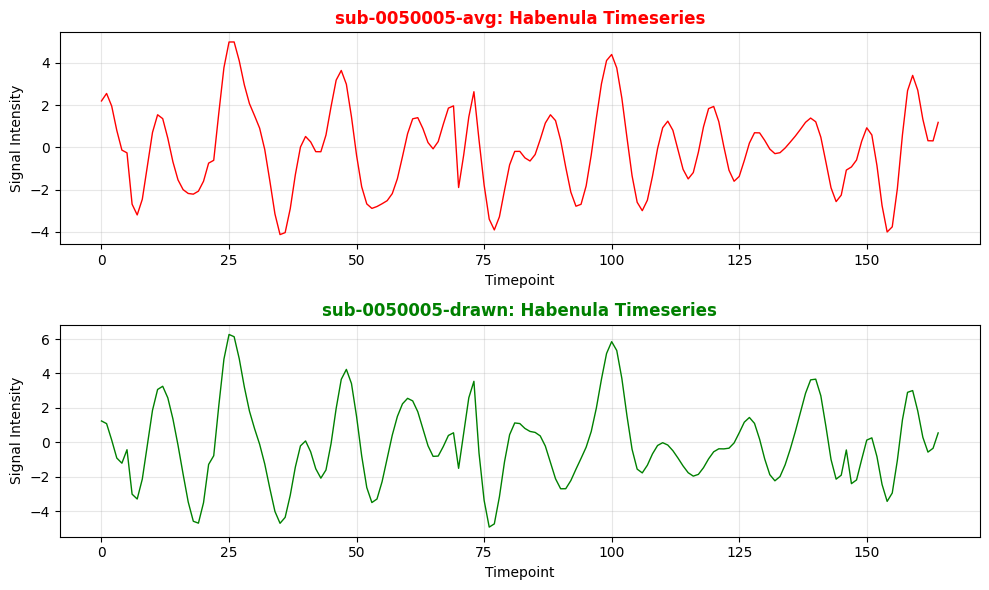

In [40]:
# Load and plot habenula timeseries for both directories
subject_dirs = [
    "/Users/chloehampson/Desktop/habenula-abide-rsfc/dset/sub-0050005-avg",
    "/Users/chloehampson/Desktop/habenula-abide-rsfc/dset/sub-0050005-drawn"
]

colors = ['red', 'green']  # red for avg, green for drawn

fig, axes = plt.subplots(2, 1, figsize=(10, 6))

for idx, subj_dir in enumerate(subject_dirs):
    # Find the habenula timeseries file
    ts_files = [f for f in os.listdir(subj_dir) if 'timeseries.txt' in f]
    
    if ts_files:
        ts_path = op.join(subj_dir, ts_files[0])
        timeseries = np.loadtxt(ts_path)
        
        ax = axes[idx]
        ax.plot(timeseries, linewidth=1, color=colors[idx])
        ax.set_title(f'{op.basename(subj_dir)}: Habenula Timeseries', color=colors[idx], fontweight='bold')
        ax.set_xlabel('Timepoint')
        ax.set_ylabel('Signal Intensity')
        ax.grid(True, alpha=0.3)

plt.tight_layout()
fig_fn = op.join(subject_dirs[0], "habenula_timeseries.png")
fig.savefig(fig_fn, dpi=300, bbox_inches='tight')
print(f"Saved: {fig_fn}")
display(fig)
plt.close()

Saved: /Users/chloehampson/Desktop/habenula-abide-rsfc/dset/sub-0050005-avg/design_matrix.png


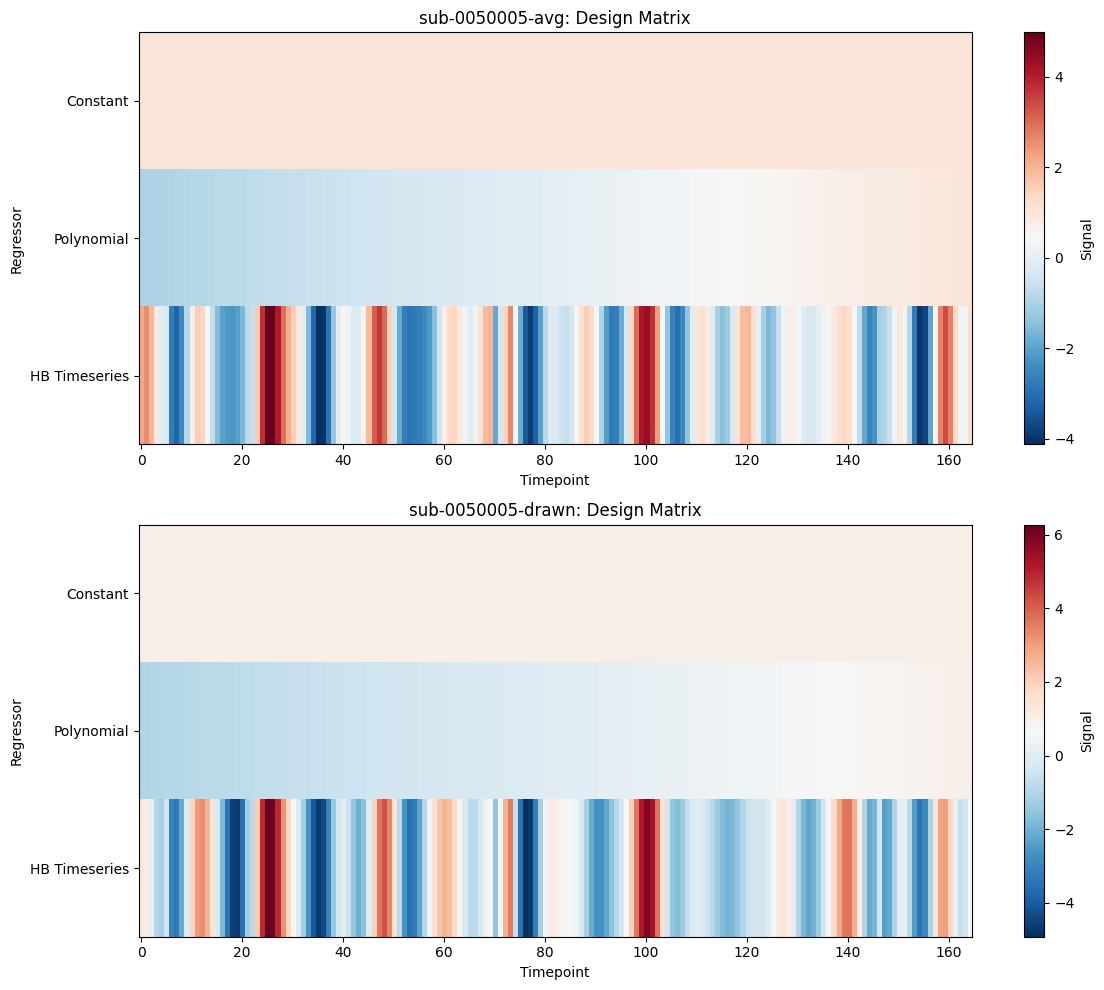

In [60]:
# Load and plot design matrix heatmaps for both directories
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

for idx, subj_dir in enumerate(subject_dirs):
    # Find the design matrix file
    matrix_files = [f for f in os.listdir(subj_dir) if 'dmatrix.1D' in f]
    
    if matrix_files:
        matrix_path = op.join(subj_dir, matrix_files[0])
        
        # Read the .1D file, skipping header lines
        with open(matrix_path, 'r') as f:
            lines = f.readlines()
        
        # Find where data starts (after the # > line)
        data_start = 0
        for i, line in enumerate(lines):
            if '# >' in line:
                data_start = i + 1
                break
        
        # Load the data
        matrix_data = np.loadtxt(matrix_path, skiprows=data_start)
        
        ax = axes[idx]
        im = ax.imshow(matrix_data.T, aspect='auto', cmap='RdBu_r', interpolation='nearest')
        ax.set_title(f'{op.basename(subj_dir)}: Design Matrix')
        ax.set_xlabel('Timepoint')
        ax.set_ylabel('Regressor')
        ax.set_yticks([0, 1, 2])
        ax.set_yticklabels(['Constant', 'Polynomial', 'HB Timeseries'])
        plt.colorbar(im, ax=ax, label='Signal')

plt.tight_layout()
fig_fn = op.join(subject_dirs[0], "design_matrix.png")
fig.savefig(fig_fn, dpi=300, bbox_inches='tight')
print(f"Saved: {fig_fn}")
display(fig)
plt.close()

++ 3dAFNItoNIFTI: AFNI version=AFNI_25.3.00 (Dec  1 2025) [64-bit]
++ 3dAFNItoNIFTI: AFNI version=AFNI_25.3.00 (Dec  1 2025) [64-bit]
++ 3dAFNItoNIFTI: AFNI version=AFNI_25.3.00 (Dec  1 2025) [64-bit]
/var/folders/x1/rzvtxb3x273_5fvyk8ftl70r0000gn/T/ipykernel_25624/716989116.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/x1/rzvtxb3x273_5fvyk8ftl70r0000gn/T/ipykernel_25624/716989116.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: /Users/chloehampson/Desktop/habenula-abide-rsfc/dset/sub-0050005-avg/connectivity_map_comparison.png


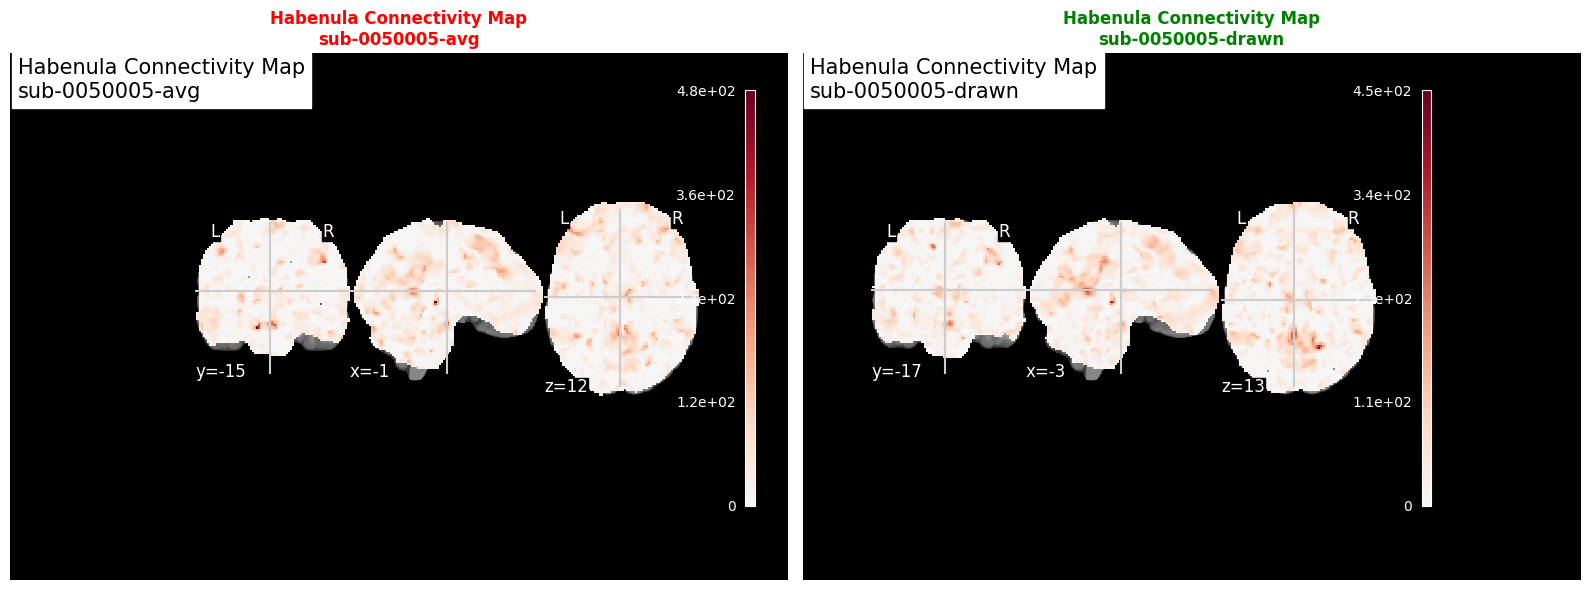

In [ ]:
# Load and visualize the .BRIK connectivity maps from both averaged and drawn folders

subject_dirs = [
    "/Users/chloehampson/Desktop/habenula-abide-rsfc/dset/sub-0050005-avg",
    "/Users/chloehampson/Desktop/habenula-abide-rsfc/dset/sub-0050005-drawn"
]

colors = ['red', 'green']  # red for avg, green for drawn

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for dir_idx, subj_dir in enumerate(subject_dirs):
    # Find any .BRIK file containing 'bucket' in the name
    brik_files = [f for f in os.listdir(subj_dir) if 'bucket' in f.lower() and f.endswith('.BRIK')]
    
    if brik_files:
        brik_path = op.join(subj_dir, brik_files[0])
        
        # Convert BRIK to NIfTI using 3dAFNItoNIFTI (get first sub-brick)
        nii_path = brik_path.replace('.BRIK', '.nii.gz')
        
        # Convert using the command
        convert_cmd = f"3dAFNItoNIFTI -prefix {nii_path} {brik_path}[0]"
        os.system(convert_cmd)
        
        # Load the converted NIfTI
        brik_img = nib.load(nii_path)
        brik_data = brik_img.get_fdata()
        
        # If 4D, take the first volume (habenula connectivity)
        if brik_data.ndim == 4:
            brik_map = brik_data[:, :, :, 0]
        else:
            brik_map = brik_data
        
        # Create NIfTI for visualization
        brik_nii = nib.Nifti1Image(brik_map, brik_img.affine)
        
        # Plot the connectivity map on subplot
        ax = axes[dir_idx]
        display_obj = plotting.plot_stat_map(
            brik_nii,
            bg_img=datasets.load_mni152_template(resolution=1),
            title=f'Habenula Connectivity Map\n{op.basename(subj_dir)}',
            colorbar=True,
            cmap=['RdBu_r', 'coolwarm'][dir_idx],
            axes=ax
        )
        # Color the title to match the condition
        ax.set_title(f'Habenula Connectivity Map\n{op.basename(subj_dir)}', color=colors[dir_idx], fontweight='bold')
    else:
        print(f"No bucket .BRIK file found in {op.basename(subj_dir)}")

plt.tight_layout()
fig_fn = op.join(subject_dirs[0], "connectivity_map_comparison.png")
fig.savefig(fig_fn, dpi=300, bbox_inches='tight')
print(f"Saved: {fig_fn}")
display(fig)
plt.close()

++ 3dAFNItoNIFTI: AFNI version=AFNI_25.3.00 (Dec  1 2025) [64-bit]



sub-0050005-avg:
  fMRI data shape: (97, 115, 97, 4)
  Voxels in ROI: 69, Timepoints: 4
  Correlation matrix shape: (69, 69)
  Correlation range: [-0.197, 1.000]


++ 3dAFNItoNIFTI: AFNI version=AFNI_25.3.00 (Dec  1 2025) [64-bit]



sub-0050005-drawn:
  fMRI data shape: (97, 115, 97, 4)
  Voxels in ROI: 69, Timepoints: 4
  Correlation matrix shape: (69, 69)
  Correlation range: [-0.335, 1.000]
Saved: /Users/chloehampson/Desktop/habenula-abide-rsfc/dset/sub-0050005-avg/voxel_correlation_matrix.png
Saved: /Users/chloehampson/Desktop/habenula-abide-rsfc/dset/sub-0050005-avg/voxel_correlation_matrix.png


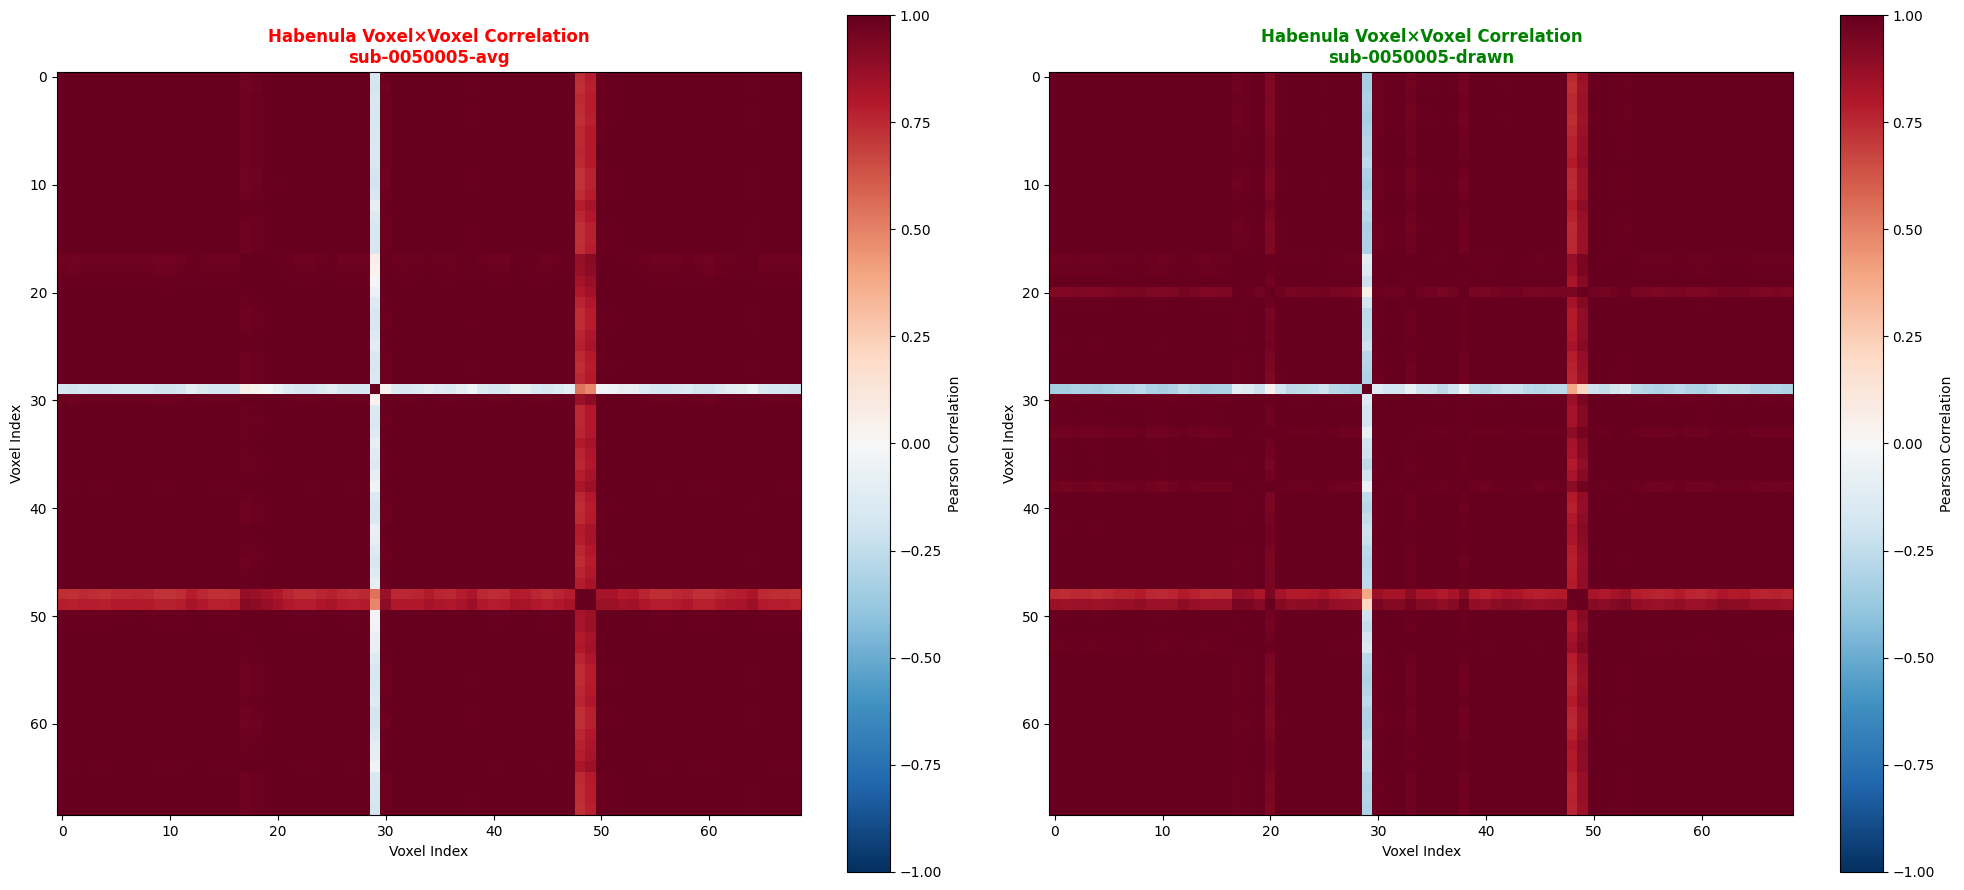

In [62]:
# Voxel x Voxel Correlation Matrix Heatmap
# Load real voxel data from bucketREML BRIK file in both averaged and drawn folders

subject_dirs = [
    "/Users/chloehampson/Desktop/habenula-abide-rsfc/dset/sub-0050005-avg",
    "/Users/chloehampson/Desktop/habenula-abide-rsfc/dset/sub-0050005-drawn"
]

colors = ['red', 'green']  # red for avg, green for drawn

fig, axes = plt.subplots(1, 2, figsize=(20, 9))

for dir_idx, subj_dir in enumerate(subject_dirs):
    # Find the bucketREML .BRIK file (4D timeseries data)
    brik_files = [f for f in os.listdir(subj_dir) if 'bucketREML' in f and f.endswith('.BRIK')]
    
    if brik_files:
        brik_path = op.join(subj_dir, brik_files[0])
        
        # Convert BRIK to NIfTI
        nii_path = brik_path.replace('.BRIK', '_4d.nii.gz')
        convert_cmd = f"3dAFNItoNIFTI -prefix {nii_path} {brik_path}"
        os.system(convert_cmd)
        
        # Load the 4D fMRI data
        fmri_img = nib.load(nii_path)
        fmri_data = fmri_img.get_fdata()
        
        # Handle extra dimensions (squeeze if necessary)
        while fmri_data.ndim > 4:
            fmri_data = fmri_data.squeeze()
        
        print(f"\n{op.basename(subj_dir)}:")
        print(f"  fMRI data shape: {fmri_data.shape}")
        
        # Load habenula mask
        hb_mask = nib.load(dil_hb_path)
        hb_mask_data = hb_mask.get_fdata() > 0
        
        # Resample mask to match fMRI space if needed
        if hb_mask_data.shape != fmri_data.shape[:3]:
            from nilearn.image import resample_to_img
            hb_mask_img = nib.Nifti1Image(hb_mask_data.astype(float), hb_mask.affine)
            hb_mask_resampled_img = resample_to_img(hb_mask_img, nib.Nifti1Image(fmri_data[:,:,:,0], fmri_img.affine), interpolation='nearest')
            hb_mask_data = hb_mask_resampled_img.get_fdata() > 0
        
        # Extract voxel timeseries within habenula ROI
        voxel_indices = np.where(hb_mask_data)
        n_voxels = len(voxel_indices[0])
        n_timepoints = fmri_data.shape[3]
        
        print(f"  Voxels in ROI: {n_voxels}, Timepoints: {n_timepoints}")
        
        if n_timepoints > 1:  # Need at least 2 timepoints for correlation
            # Extract timeseries for each voxel
            voxel_ts = np.zeros((n_voxels, n_timepoints))
            for i in range(n_voxels):
                x, y, z = voxel_indices[0][i], voxel_indices[1][i], voxel_indices[2][i]
                voxel_ts[i, :] = fmri_data[x, y, z, :]
            
            # Normalize timeseries
            voxel_ts_norm = (voxel_ts - voxel_ts.mean(axis=1, keepdims=True)) / (voxel_ts.std(axis=1, keepdims=True) + 1e-10)
            
            # Compute correlation matrix
            corr_matrix = np.corrcoef(voxel_ts_norm)
            
            print(f"  Correlation matrix shape: {corr_matrix.shape}")
            print(f"  Correlation range: [{corr_matrix.min():.3f}, {corr_matrix.max():.3f}]")
            
            # Plot on subplot
            ax = axes[dir_idx]
            im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1, interpolation='nearest')
            ax.set_title(f'Habenula Voxel×Voxel Correlation\n{op.basename(subj_dir)}', fontsize=12, fontweight='bold', color=colors[dir_idx])
            ax.set_xlabel('Voxel Index', fontsize=10)
            ax.set_ylabel('Voxel Index', fontsize=10)
            plt.colorbar(im, ax=ax, label='Pearson Correlation')
        else:
            print(f"  Only {n_timepoints} timepoint(s) - need multiple for correlation")
    
    else:
        print(f"No bucketREML BRIK file found in {op.basename(subj_dir)}")

plt.tight_layout()
fig_fn = op.join(subject_dirs[0], "voxel_correlation_matrix.png")
fig.savefig(fig_fn, dpi=300, bbox_inches='tight')
print(f"Saved: {fig_fn}")
display(fig)
plt.close()

++ 3dAFNItoNIFTI: AFNI version=AFNI_25.3.00 (Dec  1 2025) [64-bit]



sub-0050005-avg:
  fMRI data shape: (97, 115, 97, 4)
  Seed voxels: 69, Seed timeseries shape: (4,)


/Users/chloehampson/Desktop/habenula-abide-rsfc/.venv/lib/python3.9/site-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/chloehampson/Desktop/habenula-abide-rsfc/.venv/lib/python3.9/site-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


  Connectivity map range: [nan, nan]


/Users/chloehampson/Desktop/habenula-abide-rsfc/.venv/lib/python3.9/site-packages/nilearn/_utils/niimg.py:61: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  warn(
++ 3dAFNItoNIFTI: AFNI version=AFNI_25.3.00 (Dec  1 2025) [64-bit]



sub-0050005-drawn:
  fMRI data shape: (97, 115, 97, 4)
  Seed voxels: 69, Seed timeseries shape: (4,)


/Users/chloehampson/Desktop/habenula-abide-rsfc/.venv/lib/python3.9/site-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/chloehampson/Desktop/habenula-abide-rsfc/.venv/lib/python3.9/site-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


  Connectivity map range: [nan, nan]


/Users/chloehampson/Desktop/habenula-abide-rsfc/.venv/lib/python3.9/site-packages/nilearn/_utils/niimg.py:61: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  warn(
/var/folders/x1/rzvtxb3x273_5fvyk8ftl70r0000gn/T/ipykernel_25624/4270268193.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: /Users/chloehampson/Desktop/habenula-abide-rsfc/dset/sub-0050005-avg/habenula_to_brain_connectivity.png


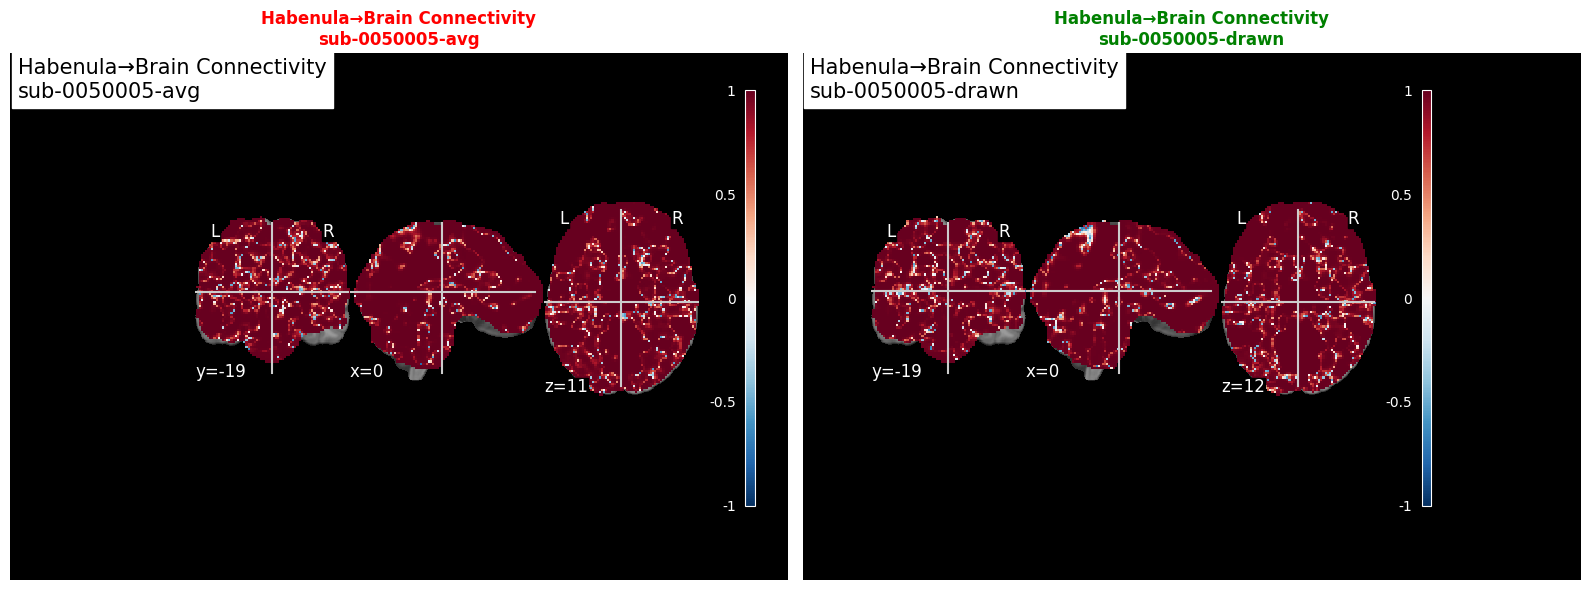

In [ ]:
# Habenula Seed to Brain Connectivity
# Correlate habenula seed timeseries against all brain voxels

subject_dirs = [
    "/Users/chloehampson/Desktop/habenula-abide-rsfc/dset/sub-0050005-avg",
    "/Users/chloehampson/Desktop/habenula-abide-rsfc/dset/sub-0050005-drawn"
]

colors = ['red', 'green']  # red for avg, green for drawn

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for dir_idx, subj_dir in enumerate(subject_dirs):
    # Find the bucketREML .BRIK file (4D timeseries data)
    brik_files = [f for f in os.listdir(subj_dir) if 'bucketREML' in f and f.endswith('.BRIK')]
    
    if brik_files:
        brik_path = op.join(subj_dir, brik_files[0])
        
        # Convert BRIK to NIfTI
        nii_path = brik_path.replace('.BRIK', '_4d.nii.gz')
        convert_cmd = f"3dAFNItoNIFTI -prefix {nii_path} {brik_path}"
        os.system(convert_cmd)
        
        # Load the 4D fMRI data
        fmri_img = nib.load(nii_path)
        fmri_data = fmri_img.get_fdata()
        
        # Handle extra dimensions (squeeze if necessary)
        while fmri_data.ndim > 4:
            fmri_data = fmri_data.squeeze()
        
        print(f"\n{op.basename(subj_dir)}:")
        print(f"  fMRI data shape: {fmri_data.shape}")
        
        # Load habenula mask
        hb_mask = nib.load(dil_hb_path)
        hb_mask_data = hb_mask.get_fdata() > 0
        
        # Resample mask to match fMRI space if needed
        if hb_mask_data.shape != fmri_data.shape[:3]:
            from nilearn.image import resample_to_img
            hb_mask_img = nib.Nifti1Image(hb_mask_data.astype(float), hb_mask.affine)
            hb_mask_resampled_img = resample_to_img(hb_mask_img, nib.Nifti1Image(fmri_data[:,:,:,0], fmri_img.affine), interpolation='nearest')
            hb_mask_data = hb_mask_resampled_img.get_fdata() > 0
        
        # Extract and average habenula seed timeseries
        seed_indices = np.where(hb_mask_data)
        n_seed_voxels = len(seed_indices[0])
        seed_ts_all = np.zeros((n_seed_voxels, n_timepoints))
        
        # Extract timeseries for each voxel in the seed ROI
        for i in range(n_seed_voxels):
            x, y, z = seed_indices[0][i], seed_indices[1][i], seed_indices[2][i]
            seed_ts_all[i, :] = fmri_data[x, y, z, :]
        
        # Average across habenula voxels
        seed_ts = seed_ts_all.mean(axis=0)
        
        # Normalize seed timeseries
        seed_ts_norm = (seed_ts - seed_ts.mean()) / (seed_ts.std() + 1e-10)
        
        print(f"  Seed voxels: {n_seed_voxels}, Seed timeseries shape: {seed_ts.shape}")
        
        # Compute correlation with all brain voxels
        x_size, y_size, z_size, n_timepoints = fmri_data.shape
        connectivity_map = np.zeros((x_size, y_size, z_size))
        
        for x in range(x_size):
            for y in range(y_size):
                for z in range(z_size):
                    voxel_ts = fmri_data[x, y, z, :]
                    # Normalize voxel timeseries
                    voxel_ts_norm = (voxel_ts - voxel_ts.mean()) / (voxel_ts.std() + 1e-10)
                    # Compute correlation with seed
                    connectivity_map[x, y, z] = np.corrcoef(seed_ts_norm, voxel_ts_norm)[0, 1]
        
        print(f"  Connectivity map range: [{connectivity_map.min():.3f}, {connectivity_map.max():.3f}]")
        
        # Create NIfTI for visualization
        connectivity_nii = nib.Nifti1Image(connectivity_map, fmri_img.affine)
        
        # Plot on subplot
        ax = axes[dir_idx]
        display_obj = plotting.plot_stat_map(
            connectivity_nii,
            bg_img=datasets.load_mni152_template(resolution=1),
            title=f'Habenula→Brain Connectivity\n{op.basename(subj_dir)}',
            colorbar=True,
            cmap=['RdBu_r', 'coolwarm'][dir_idx],
            axes=ax
        )
        # Color the title to match the condition
        ax.set_title(f'Habenula→Brain Connectivity\n{op.basename(subj_dir)}', color=colors[dir_idx], fontweight='bold')
    else:
        print(f"No bucketREML BRIK file found in {op.basename(subj_dir)}")

plt.tight_layout()
fig_fn = op.join(subject_dirs[0], "habenula_to_brain_connectivity.png")
fig.savefig(fig_fn, dpi=300, bbox_inches='tight')
print(f"Saved: {fig_fn}")
display(fig)
plt.close()

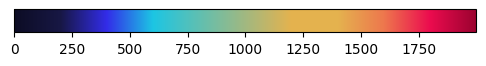

In [70]:
# Define the number of colors in the colormap
num_colors = 2000

# Define anchor points for key colors using hex values
colors = [
    "#0C0C24",  # Dark Blue
    "#171744",  # Dark Blue
    "#322ce8",
    "#1cc5e3",  # light blue
    "#5fbfb1",
    "#a1b880",
    "#E4B24E",  # Yellow (adjusted)
    "#E4B24E",  # Yellow (adjusted)
    "#ed774d",  # Orange
    "#eb0b4e",  # Red
    "#9a022f",  # Red
]
# Create a smooth interpolation for the custom colormap
CMAP = LinearSegmentedColormap.from_list("custom_cmap", colors, N=num_colors)

# Plot the color gradient
plt.figure(figsize=(8, 2))
plt.imshow([list(range(num_colors))], aspect="auto", cmap=CMAP)
plt.gca().set_visible(False)
plt.colorbar(orientation="horizontal")
display(plt.gcf())
plt.close()

++ 3dAFNItoNIFTI: AFNI version=AFNI_25.3.00 (Dec  1 2025) [64-bit]
++ 3dAFNItoNIFTI: AFNI version=AFNI_25.3.00 (Dec  1 2025) [64-bit]



sub-0050005-avg:
  fMRI data shape: (97, 115, 97, 4)
  Reshaped to: (1082035, 4) (1082035 voxels, 4 timepoints)
  Using middle 100 voxels (indices 540967-541066) for correlation matrix
  Full brain correlation matrix shape: (100, 100)
  Correlation range: [nan, nan]

sub-0050005-drawn:
  fMRI data shape: (97, 115, 97, 4)
  Reshaped to: (1082035, 4) (1082035 voxels, 4 timepoints)
  Using middle 100 voxels (indices 540967-541066) for correlation matrix
  Full brain correlation matrix shape: (100, 100)
  Correlation range: [nan, nan]
Saved: /Users/chloehampson/Desktop/habenula-abide-rsfc/dset/sub-0050005-avg/brain_voxel_correlation_matrix.png
Saved: /Users/chloehampson/Desktop/habenula-abide-rsfc/dset/sub-0050005-avg/brain_voxel_correlation_matrix.png


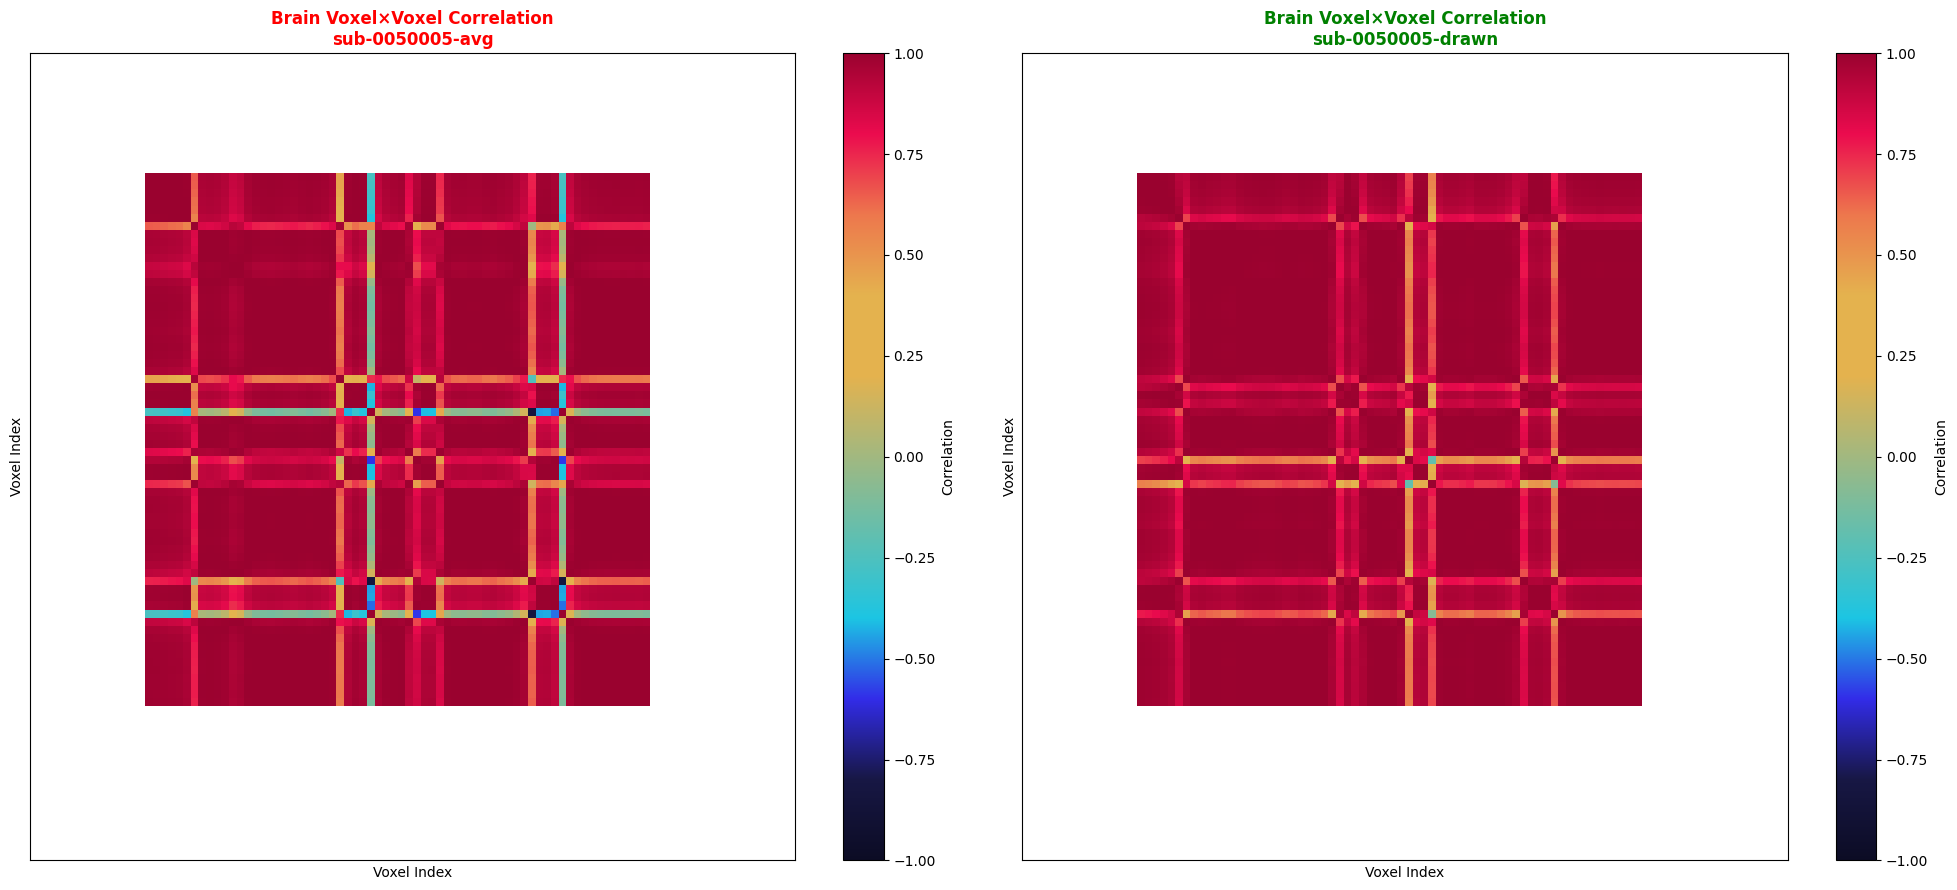

In [71]:
# Brain Voxel x Voxel Correlation Matrix Heatmap
# Correlate all brain voxels with each other (full brain connectivity matrix)

subject_dirs = [
    "/Users/chloehampson/Desktop/habenula-abide-rsfc/dset/sub-0050005-avg",
    "/Users/chloehampson/Desktop/habenula-abide-rsfc/dset/sub-0050005-drawn"
]

colors = ['red', 'green']  # red for avg, green for drawn

fig, axes = plt.subplots(1, 2, figsize=(20, 9))

for dir_idx, subj_dir in enumerate(subject_dirs):
    # Find the bucketREML .BRIK file (4D timeseries data)
    brik_files = [f for f in os.listdir(subj_dir) if 'bucketREML' in f and f.endswith('.BRIK')]
    
    if brik_files:
        brik_path = op.join(subj_dir, brik_files[0])
        
        # Convert BRIK to NIfTI
        nii_path = brik_path.replace('.BRIK', '_4d.nii.gz')
        convert_cmd = f"3dAFNItoNIFTI -prefix {nii_path} {brik_path}"
        os.system(convert_cmd)
        
        # Load the 4D fMRI data
        fmri_img = nib.load(nii_path)
        fmri_data = fmri_img.get_fdata()
        
        # Handle extra dimensions (squeeze if necessary)
        while fmri_data.ndim > 4:
            fmri_data = fmri_data.squeeze()
        
        print(f"\n{op.basename(subj_dir)}:")
        print(f"  fMRI data shape: {fmri_data.shape}")
        
        # Reshape fMRI data to (n_voxels, n_timepoints)
        x_size, y_size, z_size, n_timepoints = fmri_data.shape
        n_voxels = x_size * y_size * z_size
        fmri_2d = fmri_data.reshape(n_voxels, n_timepoints)
        
        print(f"  Reshaped to: {fmri_2d.shape} ({n_voxels} voxels, {n_timepoints} timepoints)")
        
        # Use middle 100 voxels for manageable matrix size
        start_idx = (n_voxels - 100) // 2
        fmri_subset = fmri_2d[start_idx:start_idx+100, :]
        print(f"  Using middle 100 voxels (indices {start_idx}-{start_idx+99}) for correlation matrix")
        
        # Normalize timeseries
        fmri_norm = (fmri_subset - fmri_subset.mean(axis=1, keepdims=True)) / (fmri_subset.std(axis=1, keepdims=True) + 1e-10)
        
        # Compute correlation matrix
        corr_matrix = np.corrcoef(fmri_norm)
        
        print(f"  Full brain correlation matrix shape: {corr_matrix.shape}")
        print(f"  Correlation range: [{corr_matrix.min():.3f}, {corr_matrix.max():.3f}]")
        
        # Plot on subplot
        ax = axes[dir_idx]
        im = ax.imshow(corr_matrix, cmap=CMAP, vmin=-1, vmax=1, interpolation='nearest', aspect='auto')
        ax.set_title(f'Brain Voxel×Voxel Correlation\n{op.basename(subj_dir)}', fontsize=12, fontweight='bold', color=colors[dir_idx])
        ax.set_xlabel('Voxel Index', fontsize=10)
        ax.set_ylabel('Voxel Index', fontsize=10)
        # Remove tick labels to save space
        ax.set_xticks([])
        ax.set_yticks([])
        plt.colorbar(im, ax=ax, label='Correlation')
    else:
        print(f"No bucketREML BRIK file found in {op.basename(subj_dir)}")

plt.tight_layout()
fig_fn = op.join(subject_dirs[0], "brain_voxel_correlation_matrix.png")
fig.savefig(fig_fn, dpi=300, bbox_inches='tight')
print(f"Saved: {fig_fn}")
display(fig)
plt.close()